In [14]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [15]:
df = pd.read_csv("../data/Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [16]:
print(
    df[
        [
            "Price range",
            "Has Online delivery",
            "Has Table booking"
        ]
    ].info()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Price range          9551 non-null   int64 
 1   Has Online delivery  9551 non-null   object
 2   Has Table booking    9551 non-null   object
dtypes: int64(1), object(2)
memory usage: 224.0+ KB
None


In [17]:
price_distribution = (
    df["Price range"]
    .value_counts()
    .sort_index()
    .reset_index()
)

price_distribution.columns = [
    "Price Range",
    "Restaurant Count"
]

price_distribution

,Price Range,Restaurant Count
0,1,4444
1,2,3113
2,3,1408
3,4,586


In [18]:
delivery_by_price = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"],
    normalize="index"
) * 100

delivery_by_price.round(2)

Has Online delivery,No,Yes
Price range,,
1,84.23,15.77
2,58.69,41.31
3,70.81,29.19
4,90.96,9.04


In [19]:
booking_by_price = pd.crosstab(
    df["Price range"],
    df["Has Table booking"],
    normalize="index"
) * 100

booking_by_price.round(2)

Has Table booking,No,Yes
Price range,,
1,99.98,0.02
2,92.32,7.68
3,54.26,45.74
4,53.24,46.76


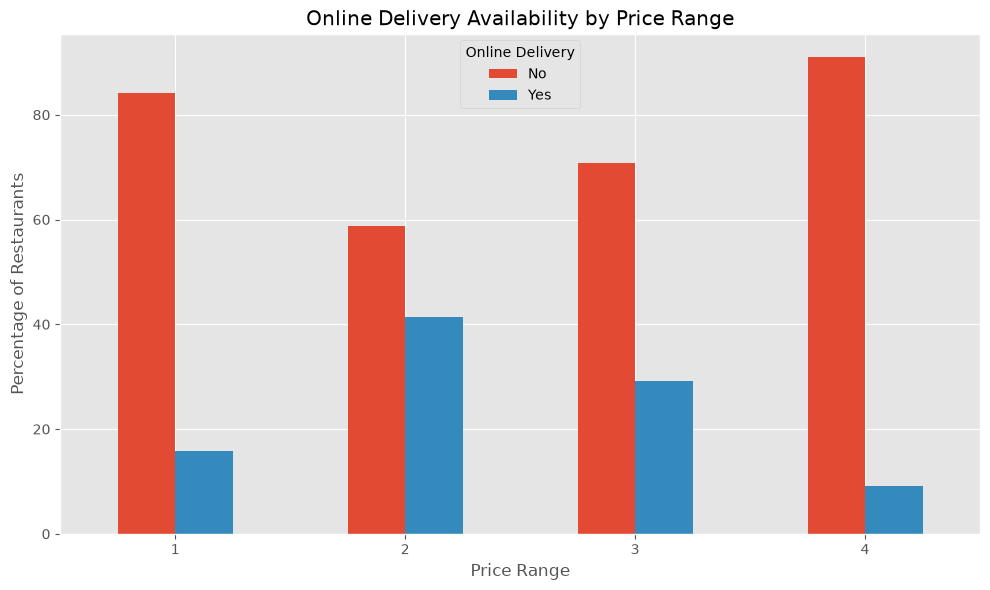

In [20]:
delivery_by_price.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants")
plt.xticks(rotation=0)
plt.legend(title="Online Delivery")

plt.tight_layout()
plt.show()

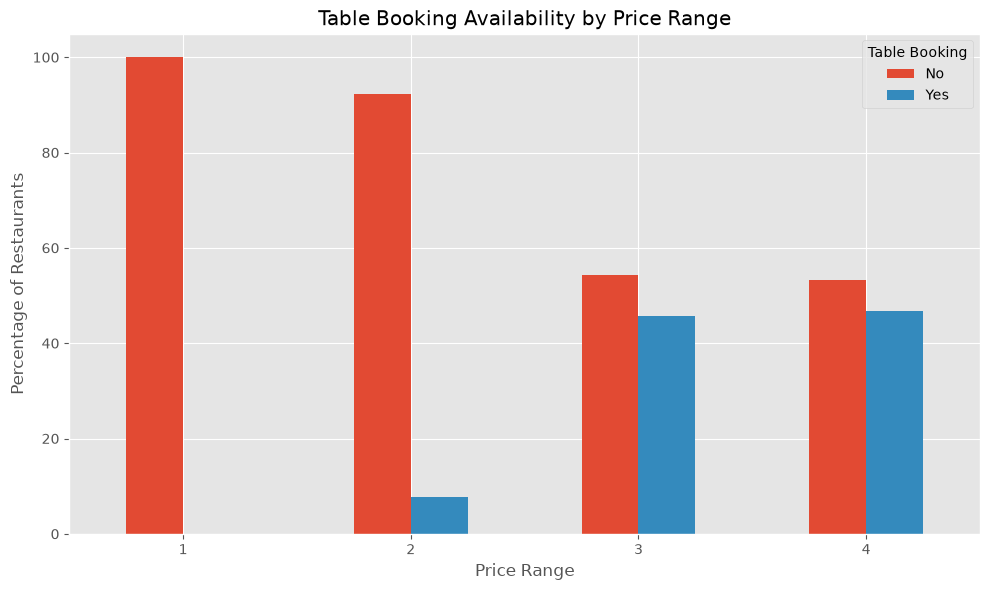

In [21]:
booking_by_price.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Table Booking Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants")
plt.xticks(rotation=0)
plt.legend(title="Table Booking")

plt.tight_layout()
plt.show()

In [22]:
combined = pd.crosstab(
    df["Price range"],
    [
        df["Has Online delivery"],
        df["Has Table booking"]
    ],
    normalize="index"
) * 100

combined.round(2)

Has Online delivery     No           Yes       
Has Table booking       No    Yes     No    Yes
Price range                                    
1                    84.23   0.00  15.75   0.02
2                    54.96   3.73  37.36   3.95
3                    44.32  26.49   9.94  19.25
4                    51.02  39.93   2.22   6.83

In [23]:
service_summary = (
    df.groupby("Price range")
      .agg(
          Online_Delivery_Rate=(
              "Has Online delivery",
              lambda x: (x == "Yes").mean() * 100
          ),
          Table_Booking_Rate=(
              "Has Table booking",
              lambda x: (x == "Yes").mean() * 100
          )
      )
      .reset_index()
)

service_summary[
    [
        "Online_Delivery_Rate",
        "Table_Booking_Rate"
    ]
] = service_summary[
    [
        "Online_Delivery_Rate",
        "Table_Booking_Rate"
    ]
].round(2)

service_summary

,Price range,Online_Delivery_Rate,Table_Booking_Rate
0,1,15.77,0.02
1,2,41.31,7.68
2,3,29.19,45.74
3,4,9.04,46.76


In [24]:
lowest_price = service_summary.iloc[0]
highest_price = service_summary.iloc[-1]

print("Lowest Price Range:")
print(lowest_price)

print("\nHighest Price Range:")
print(highest_price)

Lowest Price Range:
Price range              1.00
Online_Delivery_Rate    15.77
Table_Booking_Rate       0.02
Name: 0, dtype: float64

Highest Price Range:
Price range              4.00
Online_Delivery_Rate     9.04
Table_Booking_Rate      46.76
Name: 3, dtype: float64


In [25]:
delivery_change = (
    highest_price["Online_Delivery_Rate"]
    - lowest_price["Online_Delivery_Rate"]
)

booking_change = (
    highest_price["Table_Booking_Rate"]
    - lowest_price["Table_Booking_Rate"]
)

print(
    f"Change in online delivery availability: "
    f"{delivery_change:.2f} percentage points"
)

print(
    f"Change in table booking availability: "
    f"{booking_change:.2f} percentage points"
)

Change in online delivery availability: -6.73 percentage points
Change in table booking availability: 46.74 percentage points


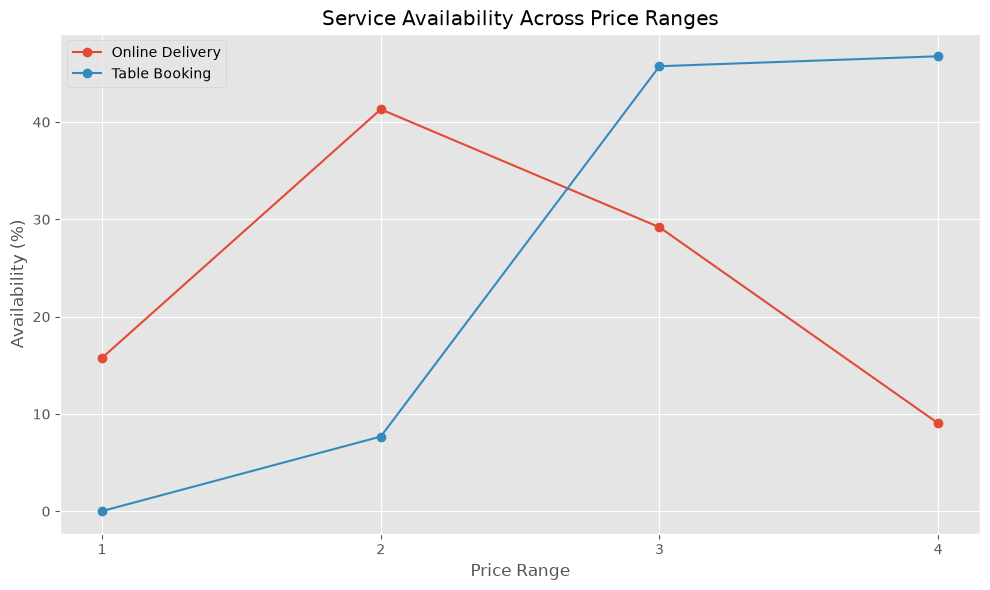

In [26]:
plt.figure(figsize=(10, 6))

x = service_summary["Price range"]

plt.plot(
    x,
    service_summary["Online_Delivery_Rate"],
    marker="o",
    label="Online Delivery"
)

plt.plot(
    x,
    service_summary["Table_Booking_Rate"],
    marker="o",
    label="Table Booking"
)

plt.title("Service Availability Across Price Ranges")
plt.xlabel("Price Range")
plt.ylabel("Availability (%)")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

# Observations

- Analyzed the relationship between restaurant price range and online delivery availability.
- Analyzed the relationship between restaurant price range and table booking availability.
- Calculated the percentage of restaurants offering each service within every price category.
- Compared service availability between the lowest and highest price ranges.
- Visualized service availability trends across price categories.
- The results indicate whether higher-priced restaurants are more likely to provide online delivery and table booking services.